# NB36 variant — 10 BPS vault redemption fee

> **Status: stored outputs predate the dataset restoration (2026-08-08).**
> This notebook reports $26,084 at 10 BPS. Re-run on the restored `hl-min-1000` data the same
> configuration gives **$30,409** with $690 of fee paid - reproduced independently by both
> `62-backtest-nb36-exit-fee-stress-0-10-20bps.ipynb` and the daily/$5 control cell of
> `65-candidate-backtest-2d-cadence-fee-drag-mitigation.ipynb`. The relative fee drag it measures
> stands; the absolute figures do not.

Based on `36-backtest-gated-inverse-vol-max6.ipynb`. The single change is a flat **10 BPS (0.10%)
fee charged on every vault sell** (Hypercore vault redemption); deposits still fill at NAV. All
NB36 selection, sizing, deposit-awareness, concentration, and capacity settings are unchanged.

This repeats on NB36 (50% concentration ceiling) the exit-cost test run on NB53 (35% ceiling) in
`58-backtest-nb53-vault-redemption-fee-10bps.ipynb`. The notebook runs the same strategy twice on
the same universe — once with the fee and once without — so the fee's cost is measured directly
instead of against NB36's committed numbers.

## Key new insights and what did we learn from this experiment?

**The exit cost is the same on NB36 as on NB53, and it is set by turnover, not by the
concentration ceiling.** Final equity falls from $26,591 to $26,084 (-$507, -1.91% of final
equity) and CAGR from 6.81% to 4.74%, a 2.06 pp loss. NB53 lost 2.03 pp on the same test. The two
notebooks differ only in their 50% versus 35% weight ceiling, and that difference is worth ~0.03 pp
of fee cost — nothing.

What sets the cost is redemption volume: NB36 redeems **$485,952 over the 11-month window, 19.4x
the $25,000 bankroll**, across 655 vault sells. The drag is therefore `redemption turnover x fee`
= 19.4 x 10 BPS = 1.94%, and the realised drag is 1.91% of final equity. NB53's slightly tighter
ceiling produced slightly less turnover (18.7x) and slightly less cost (1.87%), in the same ratio.
This confirms the NB58 rule of thumb across a second configuration: **each 1 BPS of redemption fee
costs roughly 0.20 pp of annual return at the current daily cadence.**

Consequences:

- The fee is a property of the *cadence*, not of any single sizing parameter. Tuning
  concentration, breadth or pool caps will not recover it; only trading less will. The cadence
  work in `55-opt-rebalance-cadence-minimum-hold.ipynb` and
  `56-opt-cadence-hold-concentration-breadth.ipynb` should be re-scored with a redemption fee
  applied, because at 19x turnover the optimiser is currently pricing rebalances as free.
- At 10 BPS the fee consumes about 30% of this run's gross return. At 50 BPS the strategy would
  be flat to negative on this data snapshot.

The fee does **not** change what the strategy trades: both runs hold the same 89 distinct
positions and execute the same 1,279 trades. The 10 BPS haircut is far below the rebalance
thresholds, so it is a pure cost effect on an otherwise identical path.

## Summary of results

Period 2025-08-01 to 2026-07-09, starting equity $25,000, six-vault gated inverse-volatility
basket, 50% concentration ceiling, 15% pool cap, deposit-aware. Both rows come from this
notebook, on the same 2026-08-08 data snapshot and the same trading universe.

| Metric | No redemption fee | 10 BPS redemption fee | Difference |
|---|---:|---:|---:|
| Final equity | $26,591 | $26,084 | -$507 |
| Cumulative return | 6.37% | 4.34% | -2.03 pp |
| CAGR | 6.81% | 4.74% | -2.06 pp |
| Sharpe | 0.53 | 0.39 | -0.14 |
| Sortino | 0.73 | 0.54 | -0.19 |
| Maximum drawdown | -13.99% | -14.95% | -0.95 pp |
| Distinct positions | 89 | 89 | 0 |
| Trades | 1,279 | 1,279 | 0 |

Fee accounting for the fee run:

| Quantity | Value |
|---|---:|
| Vault sell trades | 655 (83 full closes, 572 partial reductions) |
| Redemption volume | $485,952 (19.4x initial capital) |
| Redemption fee paid | $486 (1.95% of initial capital) |
| Final equity difference vs no-fee run | -$507 |

The $21 gap between the $486 of fees paid and the $507 of lost equity is the mark-to-redemption
haircut still carried by the open positions at the end of the window, plus the return foregone on
capital paid away earlier in the run.

Side by side with the NB53 run of the same test:

| | NB59 (NB36, 50% ceiling) | NB58 (NB53, 35% ceiling) |
|---|---:|---:|
| Redemption turnover | 19.4x | 18.7x |
| Fee paid | $486 | $467 |
| CAGR cost | -2.06 pp | -2.03 pp |
| Final relative drag | -1.91% | -1.87% |

The fee is spread across the basket rather than concentrated in one vault: 22Cap $86, Citadel
$58, 69 Jump St $49, JizzJazz $43, Growi HF $41 — the largest single contributor is 18% of the
total, tracking each vault's redemption volume as expected.

## Robustness of results

**The fee measurement itself is verified and clean.**

- Both sell paths were checked against the vault's own daily share price. The median implied fee
  is exactly 0.100% for full closes (83 trades) and exactly 0.100% for partial reductions (572
  trades).
- The identical measurement on the no-fee control run has a median of exactly 0.000%, and the
  median shift between the two runs is exactly the configured 0.100% (mean shift 0.101%). The
  fat tails in the raw implied-fee distribution (mean -1.0% on full closes) are present
  identically in the control, so they are pre-existing mark-versus-close noise from Hypercore
  partial-redemption pricing, not an artefact of the fee.
- Worth knowing for future fee work: Hypercore partial reductions execute at the position's
  *marked* price (`PositionManager.adjust_position()` overrides the pricing-model price, see
  trade-executor `7e673dc6`). The fee still lands, because that mark comes from
  `BacktestValuationModel` -> `get_sell_price()` at the same cycle timestamp, but the trade's
  `planned_mid_price` is overwritten and cannot be used to measure it. Open positions are
  likewise marked net of the redemption fee, which is the conservative reading of NAV.

**The underlying run is fragile, and that is not caused by the fee.**

- Neutralising the largest 5% of profitable daily returns (six days above 1.57%) turns the
  cumulative return from 4.44% into -12.56% and Sharpe from 0.39 to -1.17. The result rests on a
  handful of days.
- The best day (2025-10-15, +5.80%) carries 11.0% of all positive daily returns — a high share.
  It is a broad move rather than one lucky vault: Growi HF +15.52% and Citadel +12.41% on the
  same day, while AI Crypto (-7.00%) and JizzJazz (-9.50%) fell, so the basket did not move as
  one block either. The curator quarantine overlap audit found no held position overlapping a
  known quarantine.
- Daily returns are mildly negatively skewed (-0.36) with excess kurtosis 24.31; the worst day
  (2026-03-16, -5.36%) is comparable in size to the best day.
- Realised profit is concentrated in Growi HF (+$2,372), roughly 39% of the top-ten positive
  realised PnL, over 88 trades and six months — a held allocation rather than one lucky trade.

**Why the levels differ from the committed notebook — measured, and only partly explained.**
NB36 reports $32,793 / 33.6% CAGR / -7.76% max DD / 101 positions. Today the same notebook,
unmodified, produces $26,591 / 89 positions / 1,279 trades — exactly this notebook's no-fee
baseline, so neither the fee nor the variant machinery is involved.

The gap was decomposed by re-running NB36 against archived vault data vintages, pointed at an
isolated cache via `load_partial_data(vault_history_download_root=...)` so the shared cache was
never touched:

| Run | Vault price data | Vault metadata | Final equity | Max DD | Positions | Trades |
|---|---|---|---:|---:|---:|---:|
| NB36 as committed (ran 2026-07-23) | 2026-07-23 vintage | 2026-07-23 | $32,793 | -7.76% | 101 | 1,275 |
| Archived data, today's code | 2026-07-15 | 2026-07-22 | $27,925 | -20.3% | 127 | 1,329 |
| Archived prices, current metadata | 2026-07-15 | 2026-08-07 | $27,795 | -20.0% | 128 | 1,335 |
| Current data, today's code | 2026-08-07 | 2026-08-07 | $26,591 | -13.99% | 89 | 1,279 |

**The vault data revision is real but accounts for only about a fifth of the gap** (+$1,334 of
$6,202). The dataset genuinely changed a lot — 218 of the 567 Hypercore vaults that had in-window
price history disappeared (567 -> 349), 238 of the 349 survivors were revised down and 92 up, and
the in-window 90th-percentile return fell from +57.6% to +29.4%. Some of it is clearly cleaning:
three old series returned over +1000% in the window (largest +2,842%, now -70%) and none do now.

**The remaining ~$4,868, and the drawdown difference, is not explained by the data tested.** It
comes from either the 2026-07-15 -> 2026-07-23 data window (that vintage is no longer on disk) or
from trade-executor changes since 2026-07-23 (~50 commits, several touching HyperCore settlement,
dust handling and deposit status). This has not been bisected.

The residual is concentrated in one position. NB36's thesis was that a six-vault basket kept the
IKAGI collapse (2026-06-17/18) to position size, and it reports IKAGI costing -$340 in total.
Re-run on archived data with today's code, IKAGI costs **-$3,053**, of which -$2,376 is a single
2026-06-06 -> 2026-06-20 position. IKAGI's 2026-06-17/18 collapse is -70% in both vintages, but its
full-window return was revised from +560% to +120%, so part of that allocation difference is the
revised run-up into the collapse rather than the collapse itself. On current data IKAGI is a non-event (-$54 across
five positions).

**What this means for the notebook chain:** NB36's headline numbers are not reproducible today,
and the reason is not fully understood. Treat them as a historical artefact rather than a
baseline. Everything in this notebook that matters — the -2 pp fee delta — comes from the
in-notebook A/B where both runs share one data snapshot and one library version, so it is
unaffected.

A related casualty: on current data NB36 (50% ceiling, 6.81% CAGR baseline) and NB53 (35% ceiling,
7.25% CAGR baseline) are effectively indistinguishable, so the concentration comparison NB53 was
built to make no longer separates the two configurations either.

Archived data vintages used for this decomposition are preserved in `~/code/hl-vault-cached-backup/` with a manifest and the re-run recipe.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '59-backtest-nb36-vault-redemption-fee-10bps'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Daily rebalance cadence is the validated schedule used across the research chain.
    cycle_duration = CycleDuration.cycle_1d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket per the NB35 breadth study: one slot wider than the NB29 #48
    #: optimum. Halves max drawdown vs 5 vaults by keeping fresh-entry blow-ups (IKAGI,
    #: 2026-06-17) position-sized, at a ~4.5pp CAGR cost.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. Binds in ~24% of cycles under inverse-vol
    #: sizing and costs ~3pp in-sample CAGR (NB31); kept deliberately as live-trading
    #: insurance rather than a return driver.
    max_concentration_pct = 0.50
    #: Cap position size to this share of vault TVL. NB31 showed removing it *hurts*
    #: returns, so the backtest does not depend on unrealistic pool shares.
    per_position_cap_of_pool_pct = 0.15
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.0001

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: August 2025 remains the canonical mature-universe start.
    backtest_start = datetime.datetime(2025, 8, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; this variant charges 10 BPS
    #: so the cost of the daily-rebalance turnover becomes visible.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Loaded 326 vaults from remote vault metadata, source vaults count: 326


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs:  33%|███▎      | 1/3 [00:00<00:00,  3.89it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 11.24it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,,-,-,,,-,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.67,2026-02-16 00:00:00,30 days 00:00:00,0.00,"28,035",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.09,2025-10-08 00:00:00,30 days 00:00:00,0.00,"65,250",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.97,2026-03-10 00:00:00,30 days 00:00:00,0.00,"31,126",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.32,2026-04-17 00:00:00,30 days 00:00:00,0.00,107,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,,-,-,,,-,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.20,2025-03-05 00:00:00,30 days 00:00:00,0.00,"150,636",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,1.03,2024-02-28 00:00:00,30 days 00:00:00,0.00,579,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,,-,-,,,-,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 326 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,winning fo,0.0,0.0,0.001
1,kusa,0.0,0.0,0.001
2,[ Tachyon,0.0,0.0,0.001
3,NEET WORLD,0.0,0.0,0.001
4,Edge & Hed,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
321,BTC+ Sopho,0.0,0.0,0.001
322,AI Vault T,0.0,0.0,0.001
323,Stone28^旺角,0.0,0.0,0.001
324,Anti Marti,0.0,0.0,0.001
325,HyperViper,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 10 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:   0%|          | 0/1978 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:   6%|▋         | 127/1978 [00:00<00:01, 1249.83it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  13%|█▎        | 255/1978 [00:00<00:01, 1263.47it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  19%|█▉        | 382/1978 [00:00<00:01, 1248.17it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  87%|████████▋ | 1714/1978 [00:01<00:00, 1079.20it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  93%|█████████▎| 1840/1978 [00:01<00:00, 1128.87it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads: 100%|█████████▉| 1977/1978 [00:01<00:00, 1197.06it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads: 100%|██████████| 1978/1978 [00:02<00:00, 982.78it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_329p44450c49_2021-05-06-2026-07-10_ff_cross_d1f617c70


# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2025-08-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, deposit-aware, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=CycleDuration.from_timebucket(parameters.candle_time_bucket),
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")


Final equity: $26,084  (start $25,000)
Max drawdown: -14.9%   distinct positions: 89   trades: 1279


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [10]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2025-08-01,2025-08-01,2025-08-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,75.0%,100.0%,99.0%
Cumulative Return,4.44%,-43.86%,-48.53%
CAGR﹪,4.74%,-45.99%,-50.78%
Sharpe,0.39,-1.18,-0.72
Prob. Sharpe Ratio,64.78%,12.55%,24.35%
Smart Sharpe,0.38,-1.13,-0.69
Sortino,0.54,-1.57,-1.01


# Equity curve

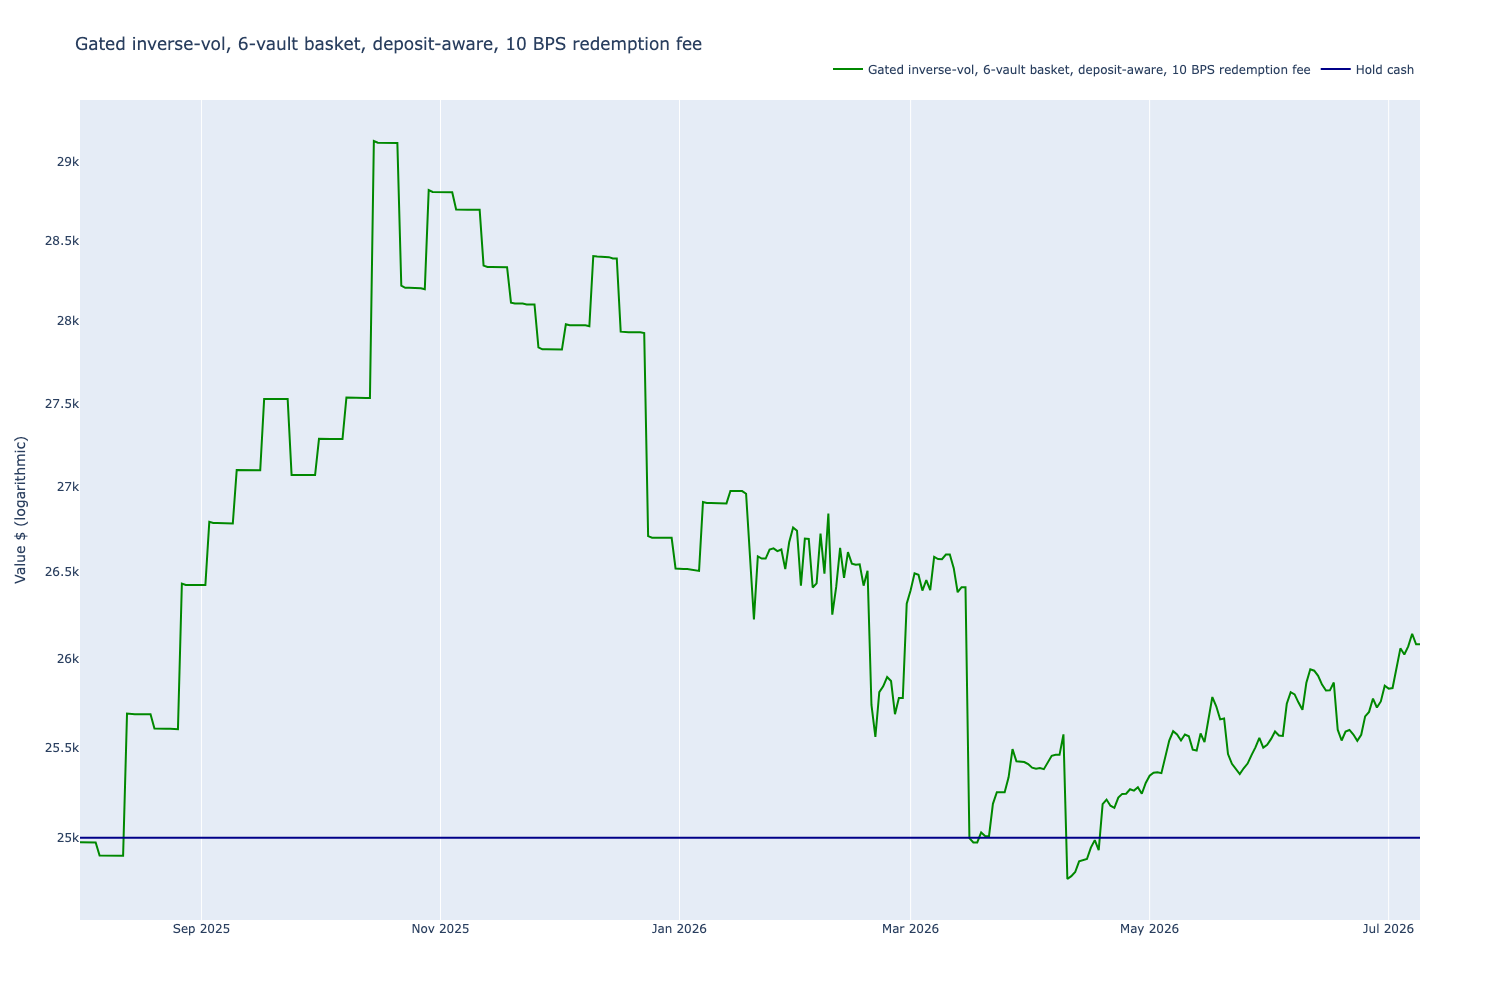

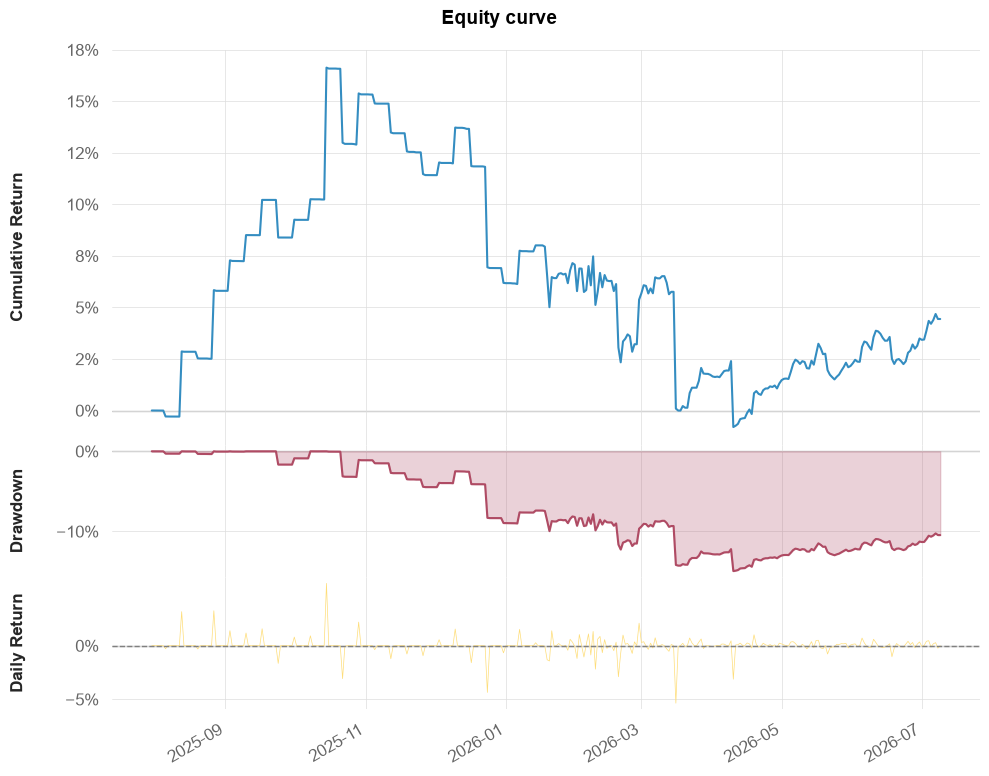

In [11]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

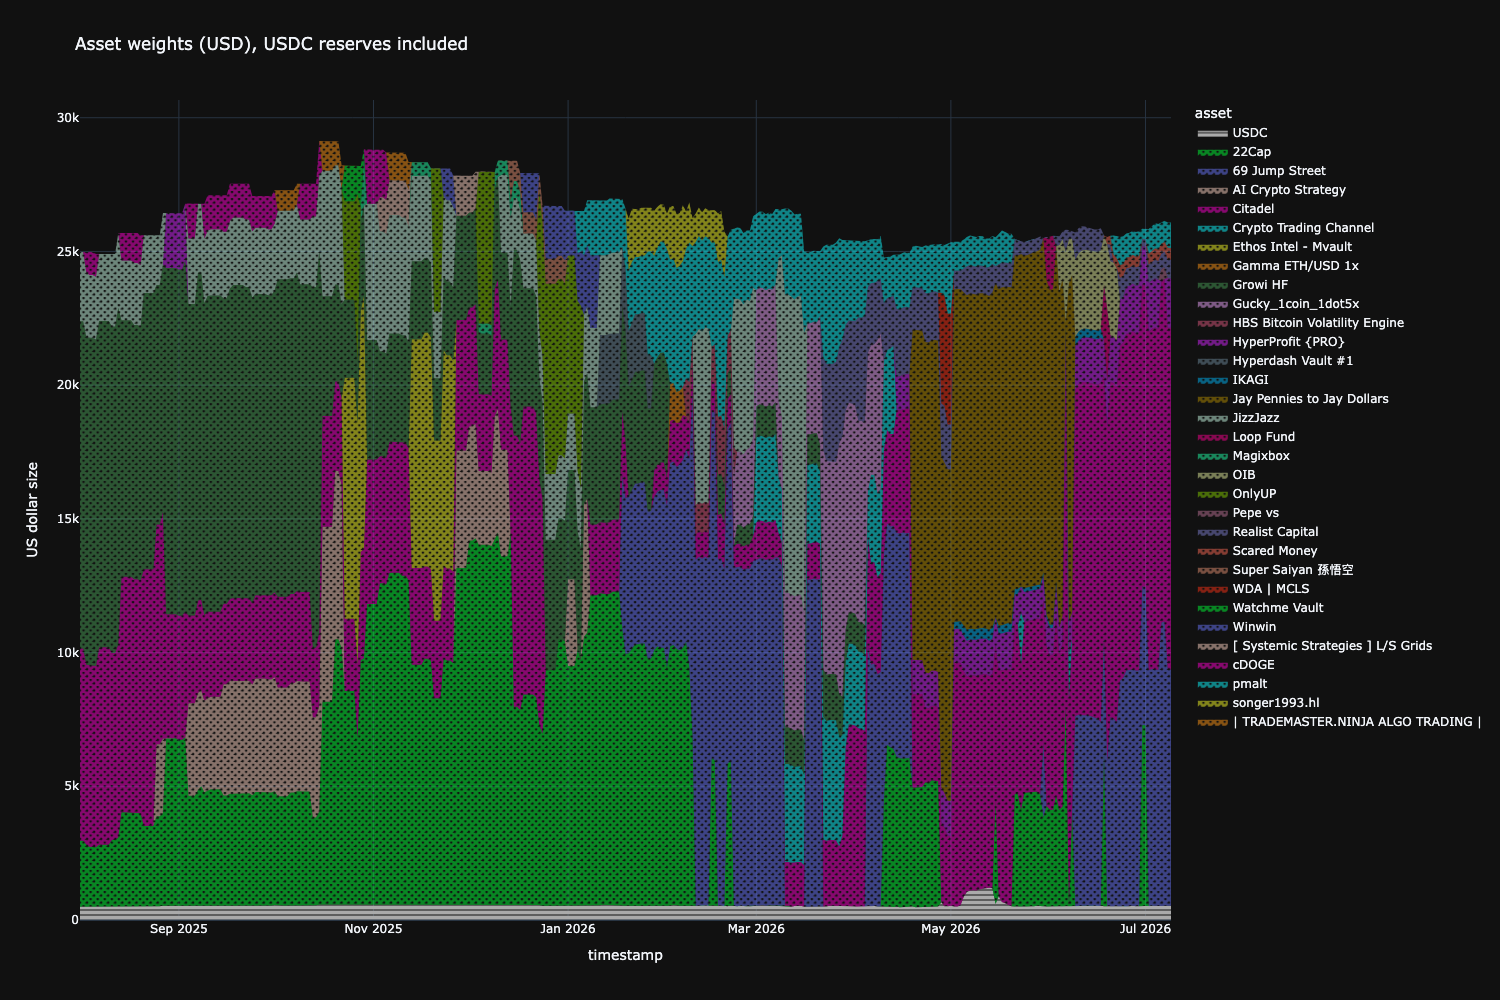

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2025-10-15,Growi HF,"$14,274.19",
Min position (excluding USDC),2026-05-30,IKAGI,$123.24,
Mean position (excluding USDC),,,"$4,480.13",
Max position (excluding USDC),2026-05-13,Jay Pennies to Jay Dollars,51.44%,
Min position (excluding USDC),2026-05-30,IKAGI,0.49%,
Mean position (excluding USDC),,,17.24%,
Max position (including USDC),2026-05-03,Jay Pennies to Jay Dollars,49.02%,
Min position (including USDC),2026-05-30,IKAGI,0.48%,
Mean position (including USDC),,,14.71%,


In [12]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

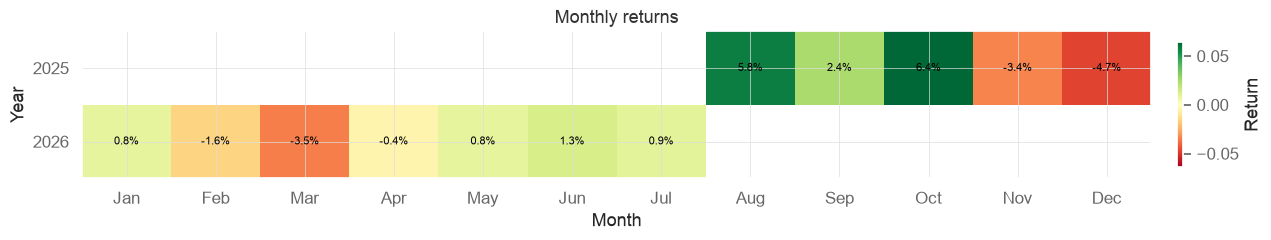

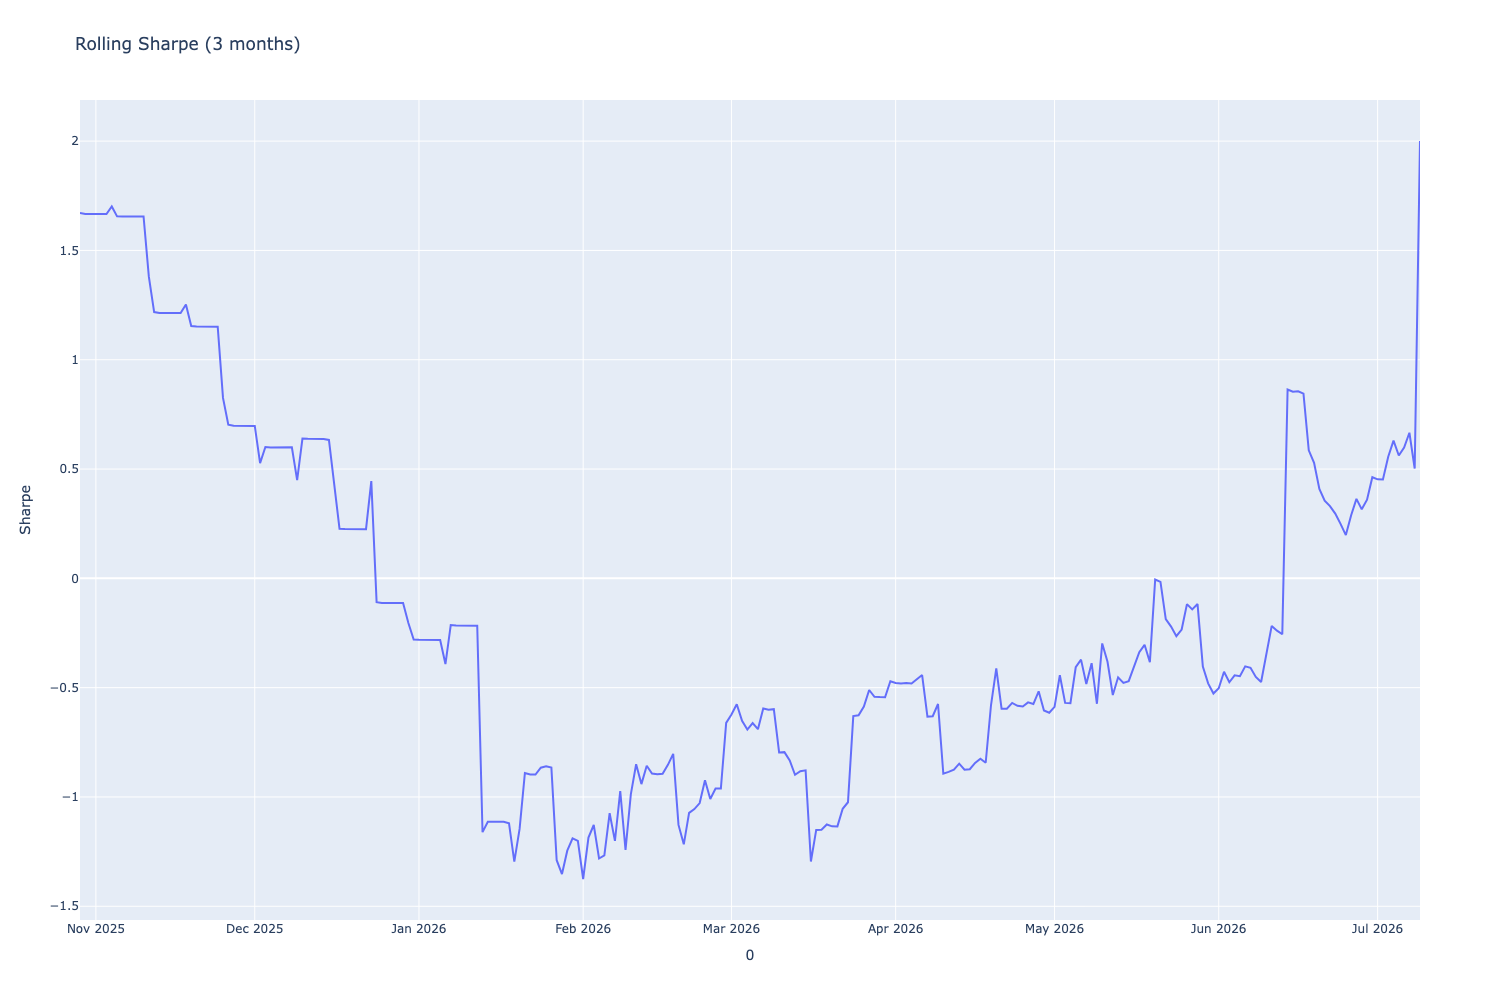

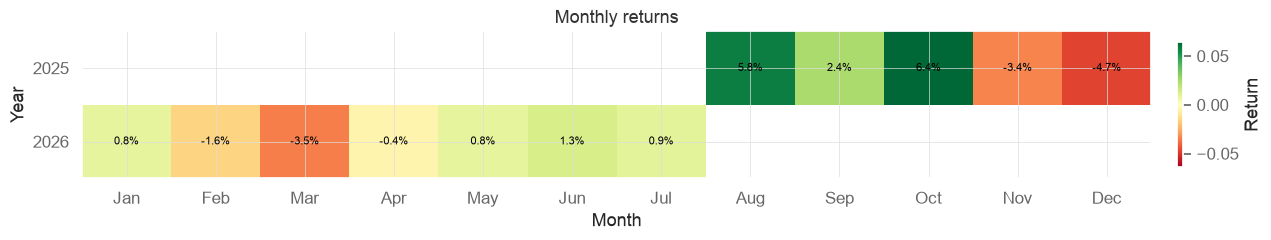

In [13]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [14]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2025-08-01,2025-08-01,2025-08-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0,0,0
Time in Market,0.75,1.0,0.99
Cumulative Return,0.04,-0.44,-0.49
CAGR﹪,0.05,-0.46,-0.51
Sharpe,0.39,-1.18,-0.72
Prob. Sharpe Ratio,0.65,0.13,0.24
Smart Sharpe,0.38,-1.13,-0.69
Sortino,0.54,-1.57,-1.01


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,2372.435707,Growi HF,2025-08-01,2026-02-02,88
1,719.378648,pmalt,2026-01-04,2026-05-21,83
2,612.176458,22Cap,2025-08-01,2026-02-10,104
3,497.400041,HyperProfi,2026-04-14,2026-07-06,36
4,465.118380,Citadel,2025-08-01,2025-12-25,69
5,407.762685,Ethos Inte,2025-10-23,2025-10-30,3
6,298.681344,Realist Ca,2026-03-22,2026-05-30,53
7,288.779544,69 Jump St,2026-01-18,2026-03-10,40
8,159.439168,Realist Ca,2026-06-23,NaT,13
9,127.794761,22Cap,2026-04-10,2026-04-28,15


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-1426.309353,JizzJazz,2026-03-08,2026-03-17,8
1,-709.731926,Citadel,2026-01-08,2026-01-20,7
2,-366.976604,| TRADEMAS,2025-10-16,2025-10-23,4
3,-366.753407,AI Crypto,2025-09-04,2025-10-23,21
4,-308.911602,cDOGE,2025-10-09,2025-10-16,4
5,-298.307173,[ Systemic,2025-11-03,2025-11-13,6
6,-292.118476,Gucky_1coi,2026-02-22,2026-04-10,38
7,-272.835188,cDOGE,2025-10-30,2025-11-06,4


,token,value,vault,protocol,link
position_id,,,,,
44,Citadel,12782.463628,Citadel,hyperliquid,0xda51323fe9800c8365646ad5c7ade0dd17fdc167
78,69 Jump St,8833.159677,69 Jump Street,hyperliquid,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802
84,pmalt,952.050197,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6
85,Realist Ca,703.111656,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
87,Scared Mon,440.576665,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
89,HyperProfi,1842.554982,HyperProfit {PRO},hyperliquid,0xc22db2c04e054786426671cec0b766c07304fb20


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,343.00
mean cash %,2.37
median cash %,2.00
max cash %,100.00
final-cycle cash %,2.00
mean deployment shortfall % of investable,0.00
cycles with shortfall > 10% of investable,0.00
mean signals pool-capped per cycle,0.22
mean signals concentration-capped per cycle,0.39
cycles where ALL selected signals were pool-capped,0.00


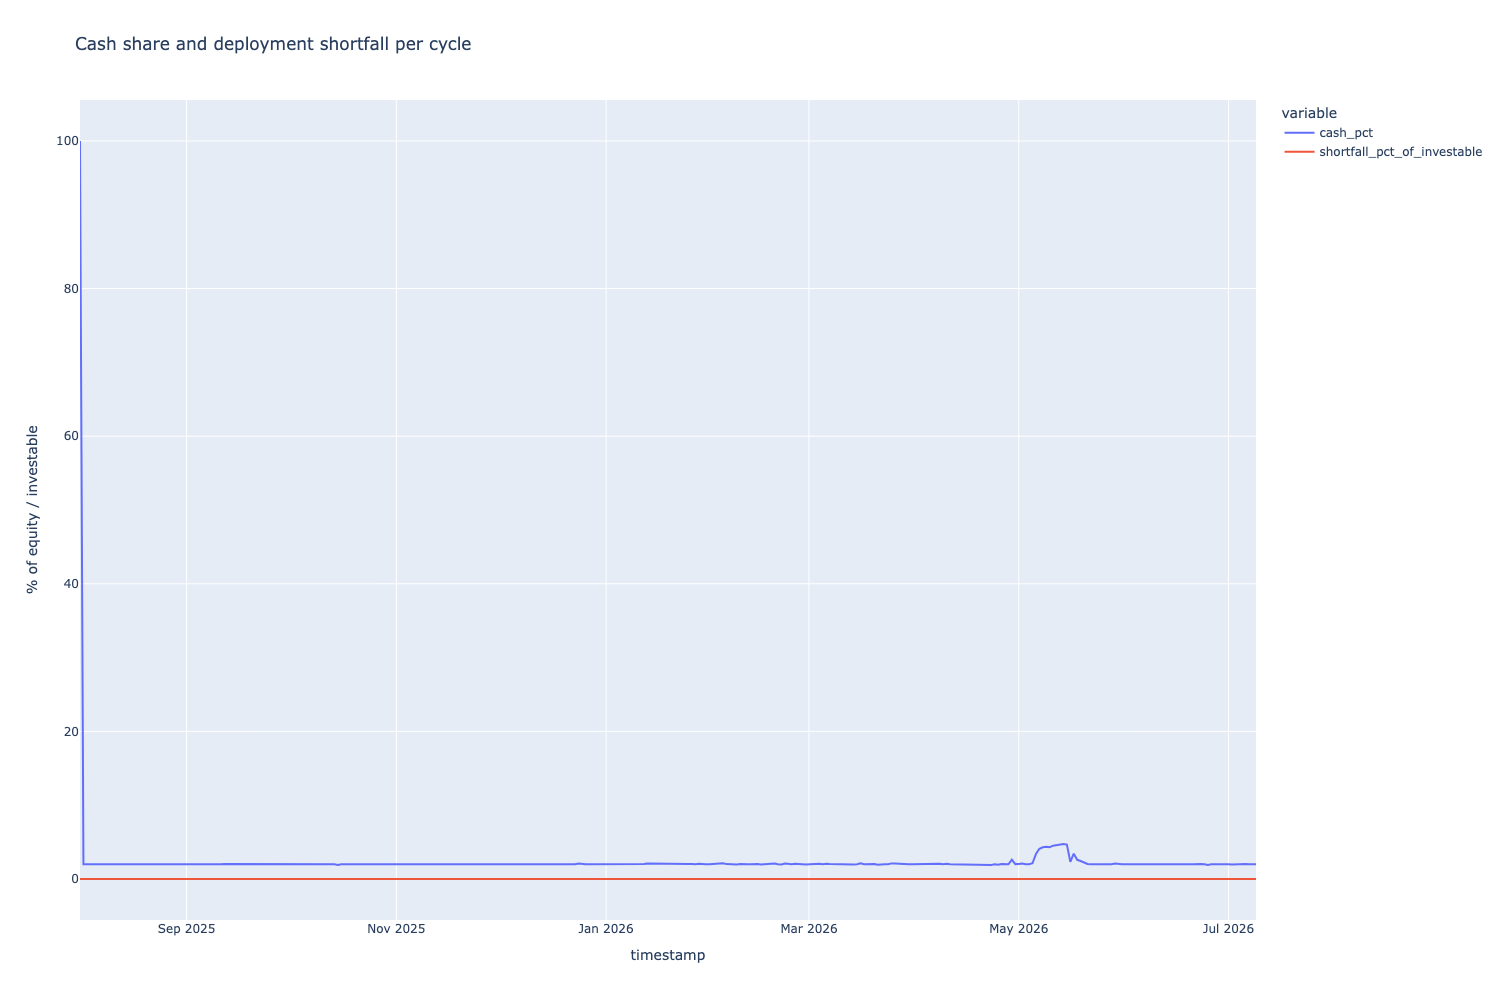

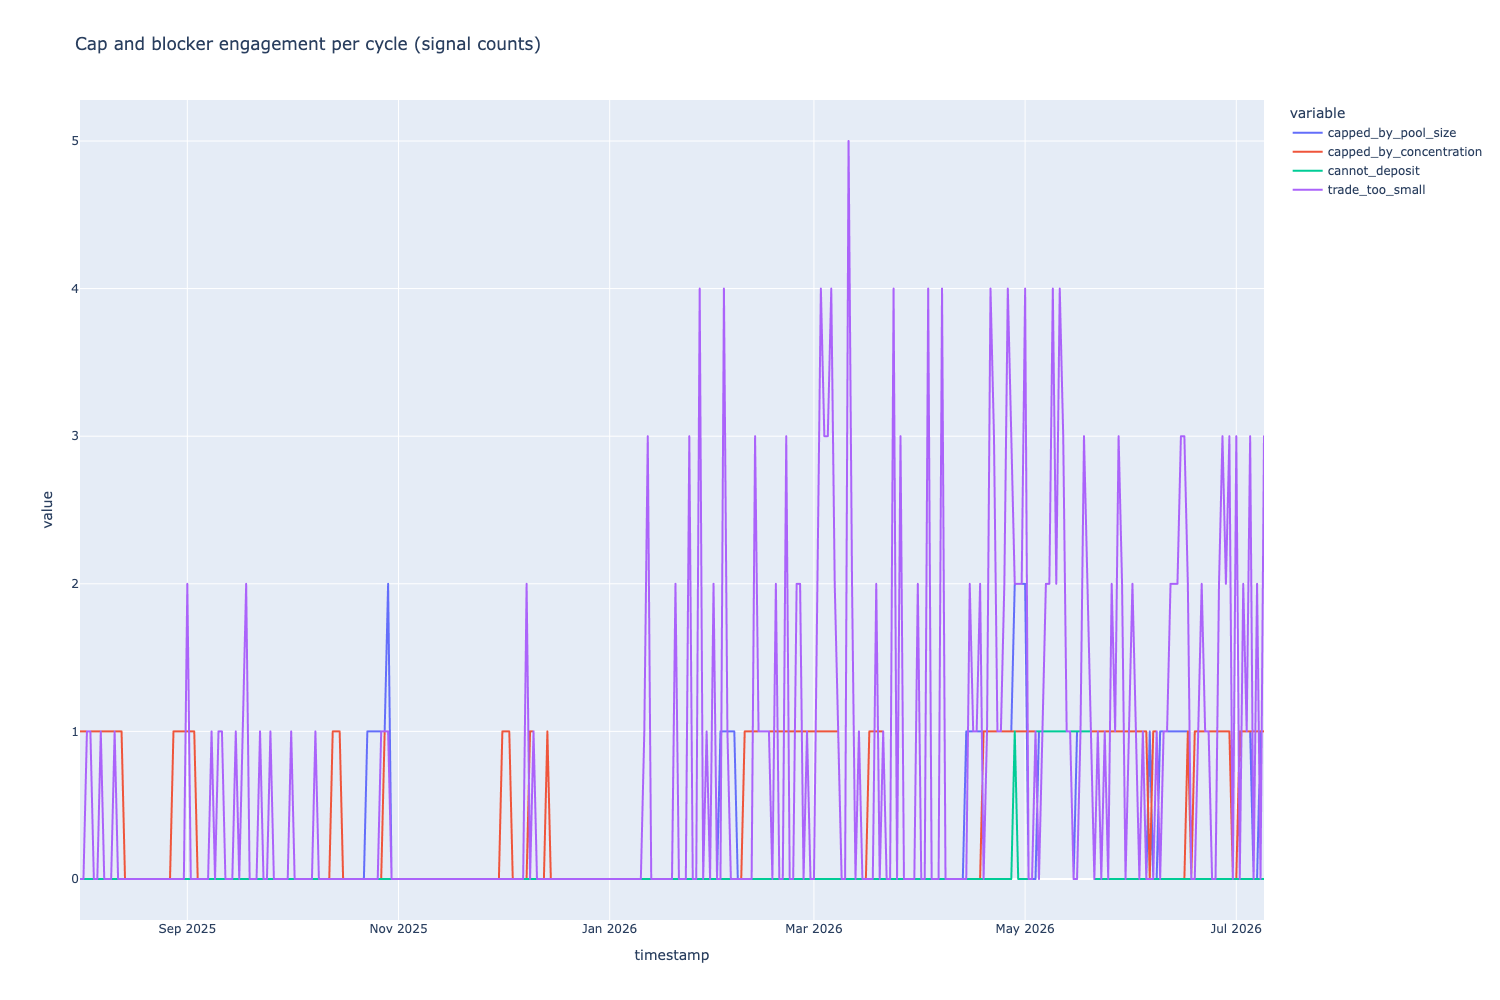

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-06-10,2.0,0,2,1,Citadel-USDC
2026-06-11,2.0,0,2,1,Citadel-USDC
2026-06-12,2.0,0,2,1,Citadel-USDC
2026-06-13,2.0,0,2,1,Citadel-USDC
2026-06-14,2.1,0,2,1,Citadel-USDC
2026-06-15,2.0,0,2,1,Citadel-USDC
2026-06-16,2.0,0,2,1,Citadel-USDC
2026-06-17,2.0,0,2,1,Citadel-USDC
2026-06-18,2.1,0,2,0,Citadel-USDC


In [15]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [16]:
final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        'Pool cap (15% of TVL) USD': last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df['Pool cap (15% of TVL) USD'].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (15% of TVL) USD
0,Citadel,12782.0,558891.0,83834.0
1,69 Jump St,8833.0,258067.0,38710.0
5,HyperProfi,1843.0,12266.0,1840.0
2,pmalt,952.0,513987.0,77098.0
3,Realist Ca,703.0,485292.0,72794.0
4,Scared Mon,441.0,50278.0,7542.0


Final cycle equity: 26,084 USD, cash: 522 USD (2.0%)
Investable (98% target): 25,562 USD, accepted by caps: 25,562 USD
Sum of pool caps across held vaults: 281,817 USD

Last cycle raw diagnostics:
Cycle: #343
Rebalanced: 👍
Open/about to open positions: 6
Max position value change: 15.96 USD
Rebalance threshold: 12.50 USD
Trades decided: 3
Pairs meeting inclusion criteria: 141
Pairs meeting TVL inclusion criteria: 145
Candidate signals created: 131
Selected survivor signals: 6
Candidates skipped for closed deposit window: 1
CAGR lookback days: 360
Sharpe lookback days: 180
CAGR weight (blend): 0.5
Total equity: 26,084.19 USD
Cash: 521.73 USD
Redeemable capital: 21,601.72 USD
Pending redemptions: 0.00 USD
Investable equity: 25,562.50 USD
Accepted investable equity: 25,562.50 USD
Allocated to signals: 25,562.50 USD
Discarded allocation because of lack of lit liquidity: 656.46 USD
Rebalance volume: 0.00 USD
Top signal pair: Citadel-USDC
Top signal value: 1087.3107103429088
Top signal weigh

# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,83,0.100%,0.100%,-1.013%,68.7%
Partial reduction,572,0.100%,0.100%,-0.075%,73.8%
All sells,655,0.100%,0.100%,-0.194%,73.1%


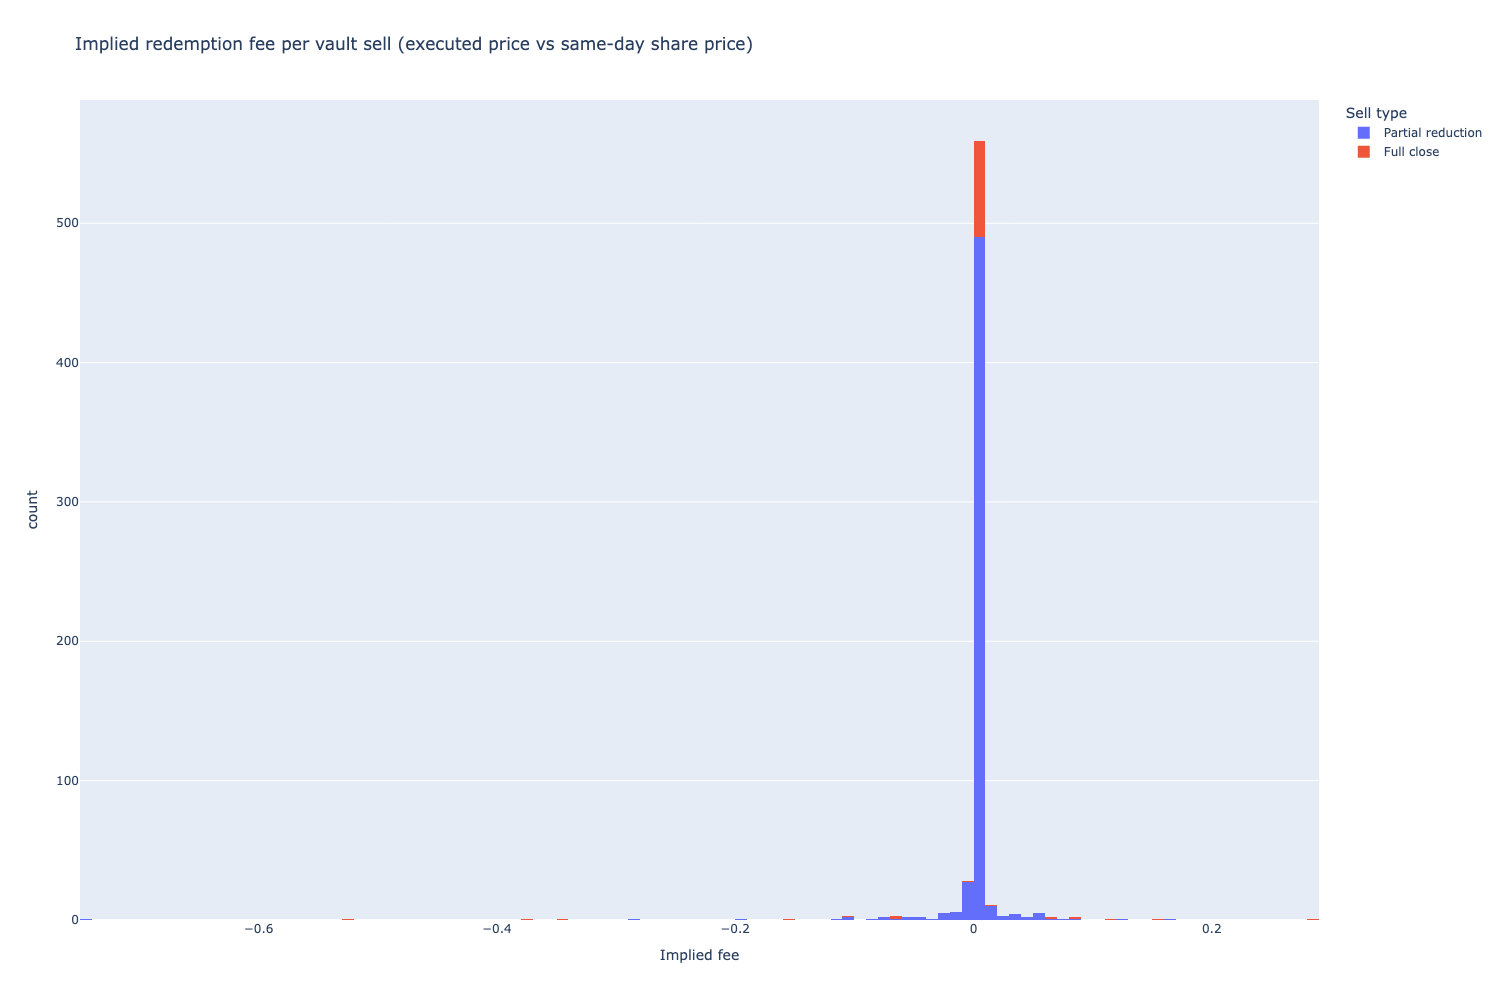

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,655,"$485,952",$486,1.95%,1.86%,19.4x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
22Cap,76,"$85,947",$86.03
Citadel,105,"$58,143",$58.20
69 Jump St,37,"$48,826",$48.87
JizzJazz,43,"$42,620",$42.66
Growi HF,65,"$40,719",$40.76
OnlyUP,8,"$25,683",$25.71
Jay Pennie,16,"$25,591",$25.62
AI Crypto,20,"$24,708",$24.73
Ethos Inte,5,"$19,451",$19.47


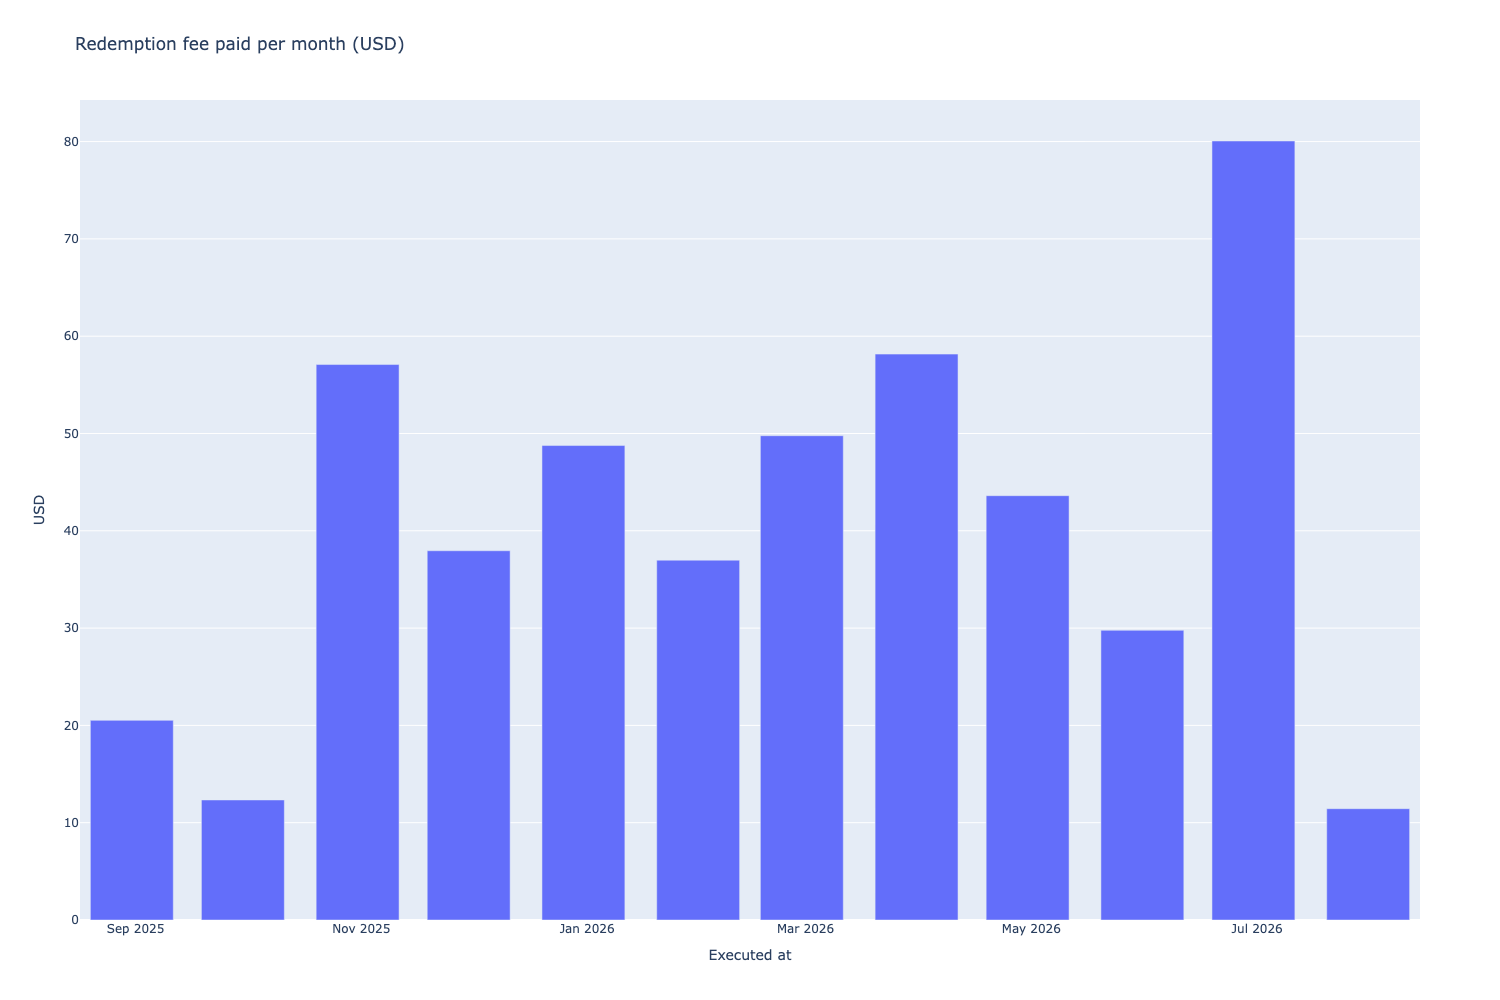

In [17]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [18]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, deposit-aware, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=CycleDuration.from_timebucket(parameters.candle_time_bucket),
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $26,591
10 BPS fee       final equity: $26,084


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$26,591",6.37%,6.81%,0.53,0.73,-13.99%,89,1279
10 BPS redemption fee,"$26,084",4.34%,4.74%,0.39,0.54,-14.95%,89,1279
Difference,$-507,-2.03%,-2.06%,-0.14,-0.19,-0.95%,0,0


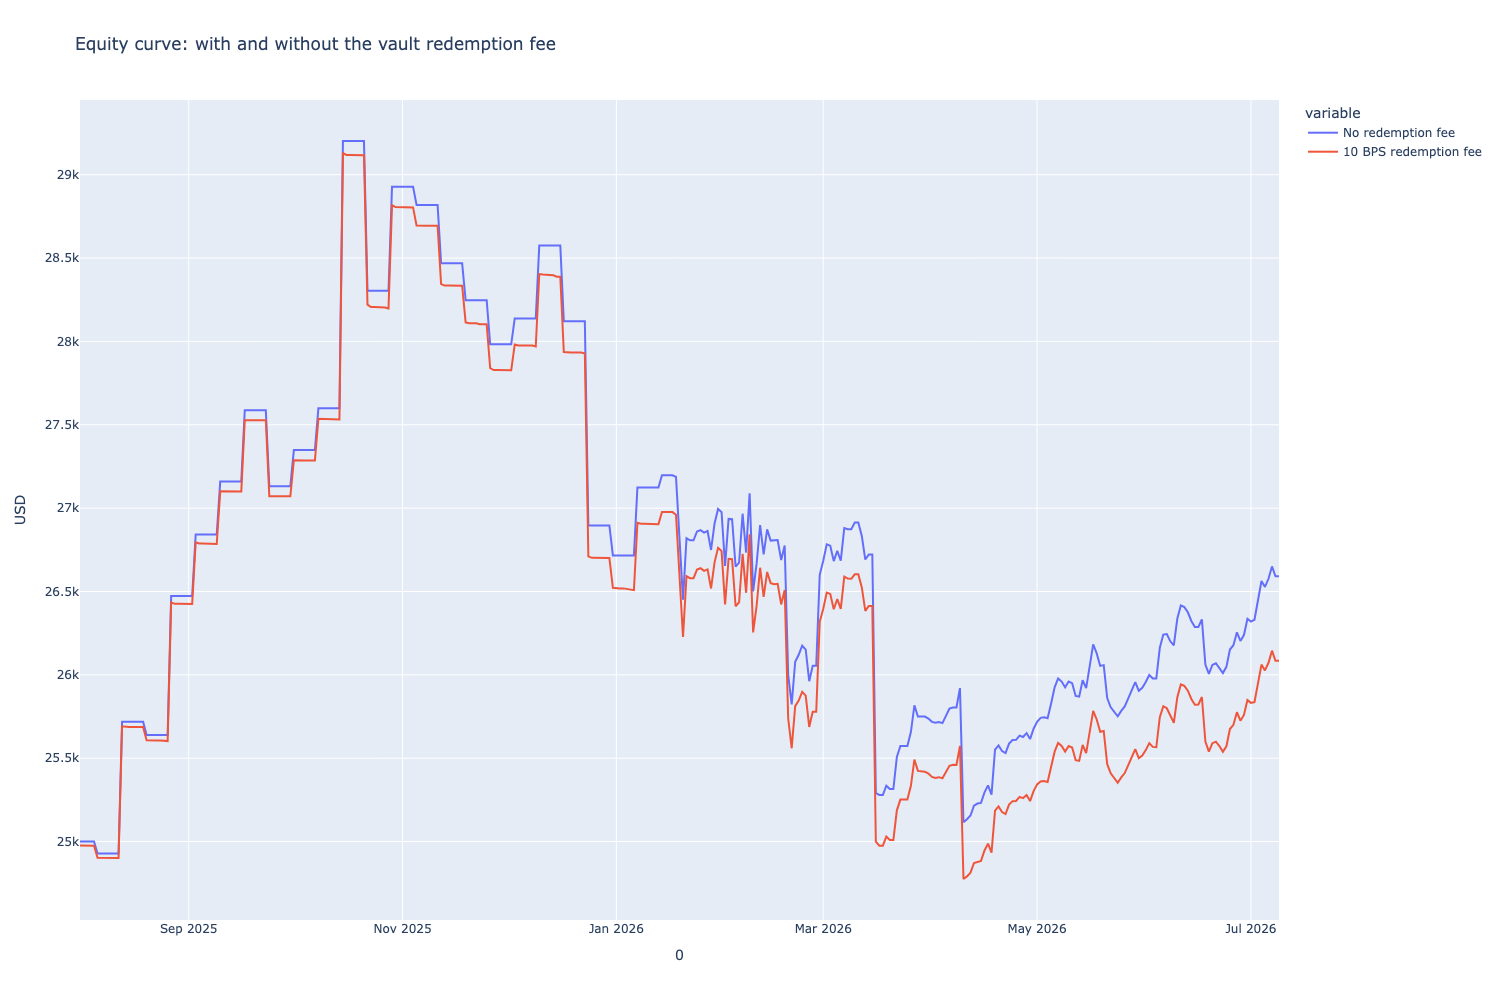

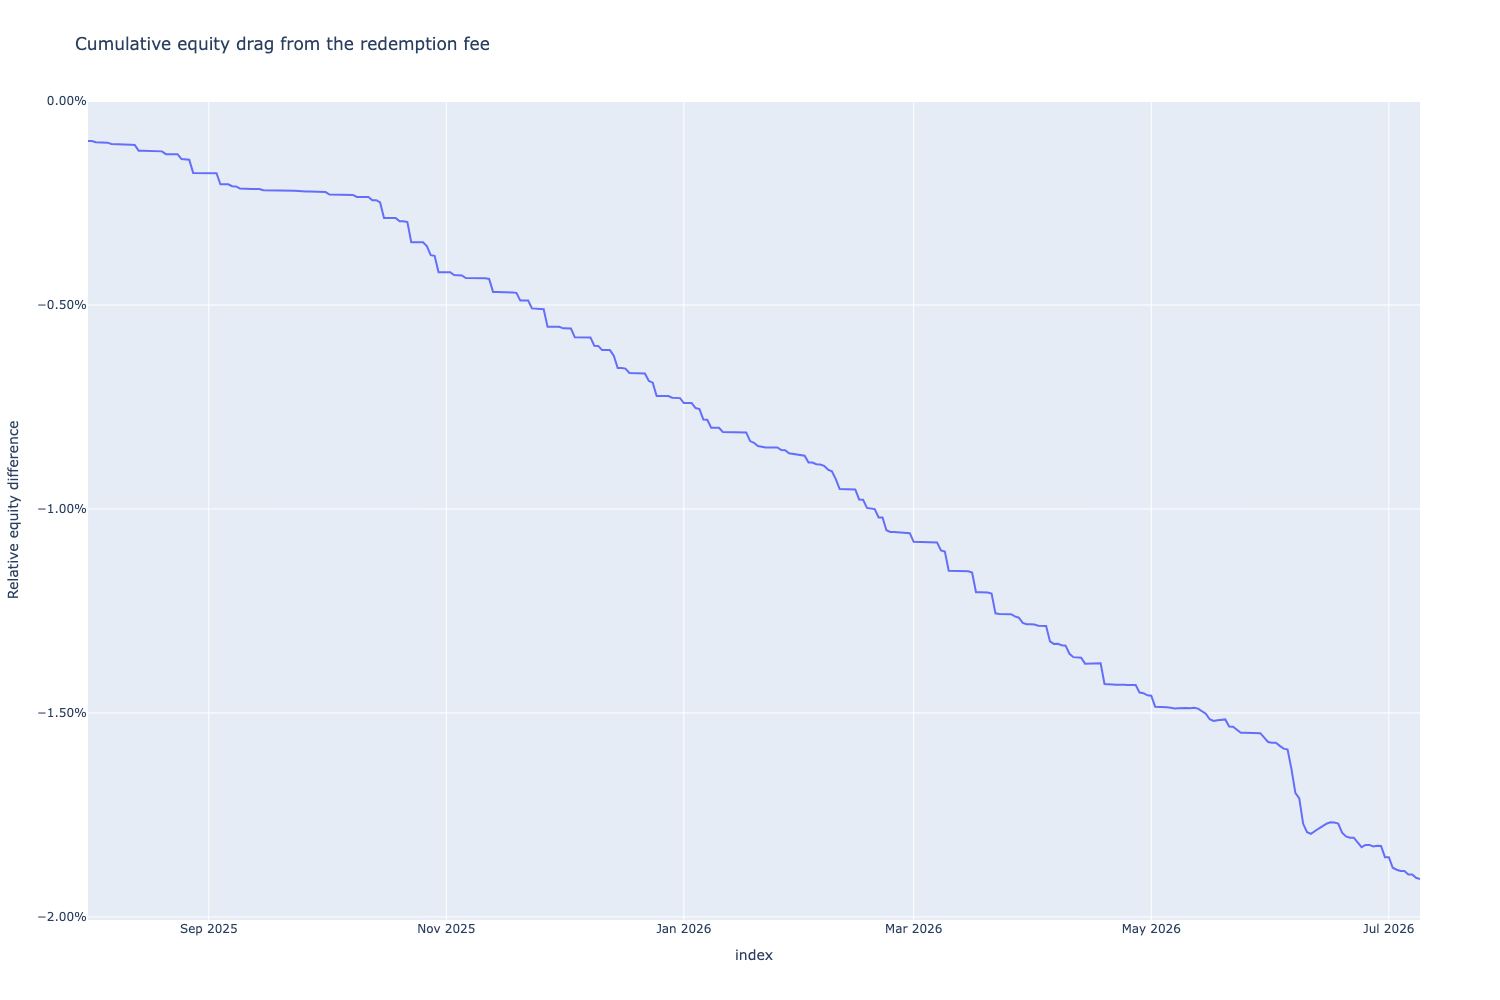

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,$-507,-1.91%,-1.91%,-2.04%,$486


In [19]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run."""
    return_series = calculate_returns(equity_curve).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [20]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.101%,0.100%


# Robustness diagnostics

In [21]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index < best_day].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return on best day': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return on best day',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return on best day': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,4.44%,4.74%,0.39,0.54,-14.95%
Largest 5% profitable daily returns neutralised,-12.56%,-13.35%,-1.17,-1.31,-18.50%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2025-10-15 00:00:00,5.80%,2026-03-16 00:00:00,-5.36%,11.0%,-0.36,24.31,6,1.57%


,Vault,Position opened,Position closed,Vault return on best day,Realised profit USD,Curator-quarantined on best day
4,Growi HF,2025-08-01 00:00:00,2026-02-02 00:00:00,15.52%,"$2,372",False
3,Citadel,2025-08-01 00:00:00,2025-12-25 00:00:00,12.41%,$465,False
5,22Cap,2025-08-01 00:00:00,2026-02-10 00:00:00,0.11%,$612,False
2,AI Crypto,2025-09-04 00:00:00,2025-10-23 00:00:00,-7.00%,$-367,False
1,JizzJazz,2025-09-04 00:00:00,2025-10-23 00:00:00,-9.50%,$-226,False
0,cDOGE,2025-10-09 00:00:00,2025-10-16 00:00:00,-25.04%,$-309,False
